In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import spacy
import seaborn as sns

In [48]:
df = pd.read_csv('./data/emotions.txt', sep=';', header=None)

In [49]:
df = df.rename(columns={0: 'text', 1: 'emotion'})

In [50]:
df.head()

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   text     16000 non-null  str  
 1   emotion  16000 non-null  str  
dtypes: str(2)
memory usage: 1.8 MB


In [52]:
nlp = spacy.load("en_core_web_sm")

text = "I am extremely happy about my new job."
doc = nlp(text)

for token in doc:
    print(token.text)

I
am
extremely
happy
about
my
new
job
.


In [53]:
# Apply spacy doc object to each row
df["doc"] = df["text"].apply(nlp)

In [54]:
# get individual words
df["tokens"] = df["doc"].apply(
    lambda doc: [token.text for token in doc]
)

In [55]:
# lemmatize words (get base words)
df["lemmas"] = df["doc"].apply(
    lambda doc: [token.lemma_ for token in doc]
)

In [56]:
df["clean_tokens"] = df["doc"].apply(
    lambda doc: [
        token.lemma_.lower()
        for token in doc
        if not token.is_punct and token.lemma_.lower() not in nlp.Defaults.stop_words
    ]
)

In [57]:
# extract adjectives
df["adjectives"] = df["doc"].apply(
    lambda doc: [
        token.text
        for token in doc
        if token.pos_ == "ADJ"
    ]
)

In [58]:
negations = {"not", "no", "never", "n't"}

def process_doc(doc):
    tokens = []
    
    for i, token in enumerate(doc):
        if token.is_punct:
            continue
            
        word = token.lemma_.lower()

        if word in negations and i + 1 < len(doc):
            next_word = doc[i + 1].lemma_.lower()
            tokens.append(f"not_{next_word}")
        elif i > 0 and doc[i - 1].lemma_.lower() in negations:
            continue
        elif not token.is_stop:
            tokens.append(word)
            
    return tokens

df["clean_tokens_neg"] = df["doc"].apply(process_doc)

In [59]:
df.head()

,text,emotion,doc,tokens,lemmas,clean_tokens,adjectives,clean_tokens_neg
0,i didnt feel humiliated,sadness,"(i, did, nt, feel, humiliated)","[i, did, nt, feel, humiliated]","[I, do, not, feel, humiliated]","[feel, humiliated]",[humiliated],"[not_feel, humiliated]"
1,i can go from feeling so hopeless to so damned...,sadness,"(i, can, go, from, feeling, so, hopeless, to, ...","[i, can, go, from, feeling, so, hopeless, to, ...","[I, can, go, from, feel, so, hopeless, to, so,...","[feel, hopeless, damned, hopeful, care, awake]","[hopeless, hopeful, awake]","[feel, hopeless, damned, hopeful, care, awake]"
2,im grabbing a minute to post i feel greedy wrong,anger,"(i, m, grabbing, a, minute, to, post, i, feel,...","[i, m, grabbing, a, minute, to, post, i, feel,...","[I, m, grab, a, minute, to, post, I, feel, gre...","[m, grab, minute, post, feel, greedy, wrong]","[greedy, wrong]","[m, grab, minute, post, feel, greedy, wrong]"
3,i am ever feeling nostalgic about the fireplac...,love,"(i, am, ever, feeling, nostalgic, about, the, ...","[i, am, ever, feeling, nostalgic, about, the, ...","[I, be, ever, feel, nostalgic, about, the, fir...","[feel, nostalgic, fireplace, know, property]",[nostalgic],"[feel, nostalgic, fireplace, know, property]"
4,i am feeling grouchy,anger,"(i, am, feeling, grouchy)","[i, am, feeling, grouchy]","[I, be, feel, grouchy]","[feel, grouchy]",[grouchy],"[feel, grouchy]"


In [60]:
# group adjectives by emotion in that row
df.groupby("emotion")["adjectives"].apply(list)

emotion
anger       [[greedy, wrong], [grouchy], [easiest, dissati...
fear        [[confused, old], [compromised, skeptical], [o...
joy         [[huge], [divine, spiritual], [immense, genera...
love        [[nostalgic], [romantic], [sad, first], [gentl...
sadness     [[humiliated], [hopeless, hopeful, awake], [li...
surprise    [[asleep, funny], [past, impressed, more, few]...
Name: adjectives, dtype: object

In [61]:
# count sentences in words
df["word_count"] = df["doc"].apply(
    lambda doc: len([token for token in doc if not token.is_punct])
)

In [62]:
df.head()

,text,emotion,doc,tokens,lemmas,clean_tokens,adjectives,clean_tokens_neg,word_count
0,i didnt feel humiliated,sadness,"(i, did, nt, feel, humiliated)","[i, did, nt, feel, humiliated]","[I, do, not, feel, humiliated]","[feel, humiliated]",[humiliated],"[not_feel, humiliated]",5
1,i can go from feeling so hopeless to so damned...,sadness,"(i, can, go, from, feeling, so, hopeless, to, ...","[i, can, go, from, feeling, so, hopeless, to, ...","[I, can, go, from, feel, so, hopeless, to, so,...","[feel, hopeless, damned, hopeful, care, awake]","[hopeless, hopeful, awake]","[feel, hopeless, damned, hopeful, care, awake]",21
2,im grabbing a minute to post i feel greedy wrong,anger,"(i, m, grabbing, a, minute, to, post, i, feel,...","[i, m, grabbing, a, minute, to, post, i, feel,...","[I, m, grab, a, minute, to, post, I, feel, gre...","[m, grab, minute, post, feel, greedy, wrong]","[greedy, wrong]","[m, grab, minute, post, feel, greedy, wrong]",11
3,i am ever feeling nostalgic about the fireplac...,love,"(i, am, ever, feeling, nostalgic, about, the, ...","[i, am, ever, feeling, nostalgic, about, the, ...","[I, be, ever, feel, nostalgic, about, the, fir...","[feel, nostalgic, fireplace, know, property]",[nostalgic],"[feel, nostalgic, fireplace, know, property]",18
4,i am feeling grouchy,anger,"(i, am, feeling, grouchy)","[i, am, feeling, grouchy]","[I, be, feel, grouchy]","[feel, grouchy]",[grouchy],"[feel, grouchy]",4


/tmp/ipykernel_24903/2027361697.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20_words.values, y=top_20_words.index, palette='viridis')


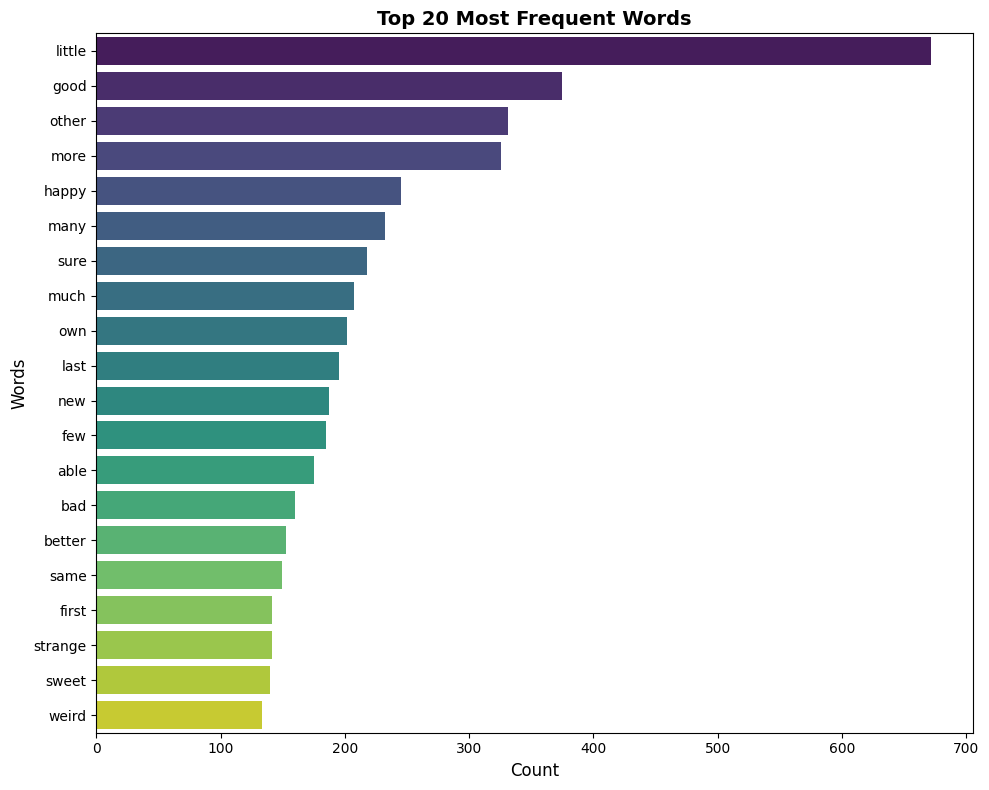

In [63]:
top_20_words = df['adjectives'].explode().value_counts().head(20)

# 2. Plot the top 20 data
plt.figure(figsize=(10, 8))  # Slightly taller to fit 20 labels comfortably
sns.barplot(x=top_20_words.values, y=top_20_words.index, palette='viridis')

# 3. Customize the chart
plt.title('Top 20 Most Frequent Words', fontsize=14, fontweight='bold')
plt.xlabel('Count', fontsize=12)
plt.ylabel('Words', fontsize=12)

plt.tight_layout()  # Ensures long word labels don't get cut off
plt.show()

In [64]:
df.head()

,text,emotion,doc,tokens,lemmas,clean_tokens,adjectives,clean_tokens_neg,word_count
0,i didnt feel humiliated,sadness,"(i, did, nt, feel, humiliated)","[i, did, nt, feel, humiliated]","[I, do, not, feel, humiliated]","[feel, humiliated]",[humiliated],"[not_feel, humiliated]",5
1,i can go from feeling so hopeless to so damned...,sadness,"(i, can, go, from, feeling, so, hopeless, to, ...","[i, can, go, from, feeling, so, hopeless, to, ...","[I, can, go, from, feel, so, hopeless, to, so,...","[feel, hopeless, damned, hopeful, care, awake]","[hopeless, hopeful, awake]","[feel, hopeless, damned, hopeful, care, awake]",21
2,im grabbing a minute to post i feel greedy wrong,anger,"(i, m, grabbing, a, minute, to, post, i, feel,...","[i, m, grabbing, a, minute, to, post, i, feel,...","[I, m, grab, a, minute, to, post, I, feel, gre...","[m, grab, minute, post, feel, greedy, wrong]","[greedy, wrong]","[m, grab, minute, post, feel, greedy, wrong]",11
3,i am ever feeling nostalgic about the fireplac...,love,"(i, am, ever, feeling, nostalgic, about, the, ...","[i, am, ever, feeling, nostalgic, about, the, ...","[I, be, ever, feel, nostalgic, about, the, fir...","[feel, nostalgic, fireplace, know, property]",[nostalgic],"[feel, nostalgic, fireplace, know, property]",18
4,i am feeling grouchy,anger,"(i, am, feeling, grouchy)","[i, am, feeling, grouchy]","[I, be, feel, grouchy]","[feel, grouchy]",[grouchy],"[feel, grouchy]",4


In [65]:
# Option 1: Load via a specific model
nlp = spacy.load("en_core_web_sm")
print(nlp.Defaults.stop_words)

# Option 2: Import directly without loading a full model pipeline
from spacy.lang.en.stop_words import STOP_WORDS
print(STOP_WORDS)

{'might', 'there', 'twenty', 'give', 'several', 'this', 'towards', 'although', "'ve", 'am', 'is', "'re", '‘s', 'former', 'through', 'latterly', 'from', 'be', 'them', 'except', 'their', 'up', 'please', 'they', 'four', 'wherever', 'does', 'to', 'ours', 'front', 'done', 'beforehand', 'anywhere', 'must', 'see', 'eleven', 'besides', 'five', 'but', 'across', 'or', 'anyone', 'already', 'it', 'being', 'every', 'those', 'cannot', 'each', 'than', 'call', 'with', 'toward', 'back', 'whatever', 'and', 'latter', 'we', 'forty', 'sixty', 'did', 'no', 'sometimes', 'other', 'himself', 'whoever', 'perhaps', 'elsewhere', 'using', 'some', 'none', 'for', 'eight', 'hundred', 'top', 'indeed', 'may', 'during', 'thus', 'whether', 'about', 'now', 'together', 'made', 'when', 'at', 'n‘t', 'neither', 'between', 'over', 'thereafter', 'whence', 'themselves', 'only', 'can', 'as', 'further', 'against', 'say', 'if', 'make', 'onto', 'itself', 'would', 'sometime', '‘ll', "'m", 'either', 'was', 'via', 'hence', 'hereafter',

In [66]:
# Words you want to test
test_words = ['not', 'never', 'no']

for word in test_words:
    # Always normalize to lowercase for accurate lookup
    is_stop = word.lower() in STOP_WORDS
    print(f"'{word}': {is_stop}")

'not': True
'never': True
'no': True


In [67]:
print(nlp("not")[0].is_stop)

True


In [68]:
df.to_csv('./data/emotions_clean.csv')